浓缩液产率

In [16]:
# 导入必要的库
import pandas as pd
import numpy as np
import joblib
import time

# 数据处理与划分
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 模型
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# 模型评估与选择
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 1. 数据加载与准备 ---
# 假设您的数据已按如下方式加载和准备好
# 注意：请确保您已安装所有必需的库 (pandas, scikit-learn, xgboost, lightgbm, catboost, openpyxl)
file_path_y2 = 'E:/基于ML优化工艺参数/20250922_best_imputed_dataset_from_run_5_y2.xlsx'
sheet_name_y2 = 'Sheet1'
data_y2 = pd.read_excel(file_path_y2, sheet_name_y2)
feature_names_y2 = ['T_t', 'T_b', 'Q_f', 'C_f', 'ΔT', 'P']
target_names_y2 = ['PR']
data_y2.columns = feature_names_y2 + target_names_y2
print(f"成功读取数据，数据形状: {data_y2.shape}")
print("数据前5行预览:")
print(data_y2.head())


成功读取数据，数据形状: (95, 7)
数据前5行预览:
    T_t   T_b       Q_f        C_f    ΔT         P        PR
0  70.9  45.4  10.61400   6.574333  25.5  4.948704  0.239017
1  66.7  43.0   9.57000   4.920000  23.7  5.010000  0.100660
2  67.8  40.2   6.26400  39.170000  27.6  4.000000  0.194632
3  67.1  44.2  10.32847   5.330000  22.9  5.000000  0.202782
4  73.0  43.6   9.36000  59.970000  29.4  4.135067  0.285256


In [17]:
print("\n--- 划分数据集 ---")
TEST_SIZE = 0.2
SPLIT_RANDOM_STATE = 9
X = data_y2[feature_names_y2]
y = data_y2[target_names_y2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SPLIT_RANDOM_STATE)
print(f"训练集形状: X-{X_train.shape}, y-{y_train.shape}")
print(f"测试集形状: X-{X_test.shape}, y-{y_test.shape}")
print("--- 数据集划分完成！ ---\n")


# --- 2. 数据标准化 (已修正) ---
print("\n--- 数据标准化 ---")
# 初始化缩放器
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# 在训练集上拟合并转换，防止数据泄露
X_train_scaled = x_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)

# 使用在训练集上学到的参数来转换测试集
X_test_scaled = x_scaler.transform(X_test)
# y_test_scaled = y_scaler.transform(y_test) # 在评估时我们会直接使用y_test，所以这一步不是必须的

print("数据标准化完成！")
print("注意: y_train 已被缩放以用于模型训练。评估指标将在原始尺度上计算。")


# --- 3. 定义九个基础预测模型及超参数网格 ---
models_and_params = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}),
    'DecisionTree': (DecisionTreeRegressor(random_state=SPLIT_RANDOM_STATE), {'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5]}),
    'RandomForest': (RandomForestRegressor(random_state=SPLIT_RANDOM_STATE), {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}),
    'ExtraTrees': (ExtraTreesRegressor(random_state=SPLIT_RANDOM_STATE), {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}),
    'SVR': (SVR(), {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}),
    'XGBoost': (xgb.XGBRegressor(random_state=SPLIT_RANDOM_STATE), {'n_estimators': [50, 100, 200], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5, 7]}),
    'LightGBM': (lgb.LGBMRegressor(random_state=SPLIT_RANDOM_STATE), {'n_estimators': [50, 100, 200], 'learning_rate': [0.05, 0.1, 0.2], 'num_leaves': [20, 31, 40]}),
    'CatBoost': (cb.CatBoostRegressor(random_state=SPLIT_RANDOM_STATE, verbose=0), {'iterations': [50, 100, 200], 'learning_rate': [0.05, 0.1, 0.2], 'depth': [4, 6, 8]}),
    'MLP': (MLPRegressor(random_state=SPLIT_RANDOM_STATE, max_iter=1000, early_stopping=True), {'hidden_layer_sizes': [(50,), (100,), (50, 50)], 'alpha': [0.0001, 0.001, 0.01]})
}

# --- 4. 训练、调优与评估循环 ---
print("\n--- 开始批量训练、调优和评估模型 ---")

best_model_name = ""
best_model_estimator = None
best_model_test_r2 = -float('inf')
model_performance_results = {}

# 遍历定义的每个模型
for model_name, (model, params) in models_and_params.items():
    print(f"\n{'='*20} 正在处理模型: {model_name} {'='*20}")
    start_time = time.time()

    # 配置网格搜索与交叉验证
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,  # 五折交叉验证
        scoring='r2',  # 以R²为评估指标
        n_jobs=-1,  # 使用所有可用的CPU核心
        verbose=0   # 设置为1或更高以查看详细日志
    )

    # 在标准化后的训练数据上进行拟合
    # y_train_scaled.ravel() 将其从 (n_samples, 1) 转换为 (n_samples,) 以满足GridSearchCV的要求
    grid_search.fit(X_train_scaled, y_train_scaled.ravel())

    # 获取最佳模型
    best_estimator = grid_search.best_estimator_
    
    # --- 在训练集上评估性能 ---
    y_train_pred_scaled = best_estimator.predict(X_train_scaled)
    # 将预测结果反标准化，以计算原始尺度的指标
    y_train_pred_orig = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
    
    train_r2 = r2_score(y_train, y_train_pred_orig)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_orig))
    train_mae = mean_absolute_error(y_train, y_train_pred_orig)

    # --- 在测试集上评估性能 ---
    y_test_pred_scaled = best_estimator.predict(X_test_scaled)
    # 将预测结果反标准化
    y_test_pred_orig = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

    test_r2 = r2_score(y_test, y_test_pred_orig)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_orig))
    test_mae = mean_absolute_error(y_test, y_test_pred_orig)

    end_time = time.time()
    
    # 打印该模型的最终性能
    print(f"模型 '{model_name}' 训练调优完成，耗时: {end_time - start_time:.2f} 秒")
    print(f"找到的最佳超参数: {grid_search.best_params_}")
    print(f"训练集表现 -> R2: {train_r2:.4f}, RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}")
    print(f"测试集表现 -> R2: {test_r2:.4f}, RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}")


    # 存储结果
    model_performance_results[model_name] = {
        'train_r2': train_r2, 'train_rmse': train_rmse, 'train_mae': train_mae,
        'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae
    }

    # 检查并更新全局最佳模型 (基于测试集R2)
    if test_r2 > best_model_test_r2:
        best_model_test_r2 = test_r2
        best_model_estimator = best_estimator
        best_model_name = model_name

# --- 5. 保存最佳模型 ---
print(f"\n{'='*25} 评估总结 {'='*25}")
print(f"所有模型已评估完毕。")
if best_model_estimator:
    print(f"在测试集上表现最佳的模型是: '{best_model_name}' (测试集 R² = {best_model_test_r2:.4f})")

    model_filename = 'best_model_y2.joblib'
    x_scaler_filename = 'x_scaler_y2.joblib'
    y_scaler_filename = 'y_scaler_y2.joblib'
    
    # 使用 joblib 保存模型和缩放器对象
    joblib.dump(best_model_estimator, model_filename)
    joblib.dump(x_scaler, x_scaler_filename)
    joblib.dump(y_scaler, y_scaler_filename)

    print(f"\n最佳模型已保存至: '{model_filename}'")
    print(f"特征缩放器 (x_scale_y2) 已保存至: '{x_scaler_filename}'")
    print(f"目标缩放器 (y_scaler_y2) 已保存至: '{y_scaler_filename}'")
    print("您可以在后续任务中加载这些文件以进行新的预测。")
else:
    print("未能找到最佳模型")
    
	


--- 划分数据集 ---
训练集形状: X-(76, 6), y-(76, 1)
测试集形状: X-(19, 6), y-(19, 1)
--- 数据集划分完成！ ---


--- 数据标准化 ---
数据标准化完成！
注意: y_train 已被缩放以用于模型训练。评估指标将在原始尺度上计算。

--- 开始批量训练、调优和评估模型 ---

==================== 正在处理模型: Ridge ====================
模型 'Ridge' 训练调优完成，耗时: 1.36 秒
找到的最佳超参数: {'alpha': 10.0}
训练集表现 -> R2: 0.4518, RMSE: 0.0703, MAE: 0.0566
测试集表现 -> R2: 0.6287, RMSE: 0.0551, MAE: 0.0458

==================== 正在处理模型: DecisionTree ====================
模型 'DecisionTree' 训练调优完成，耗时: 0.08 秒
找到的最佳超参数: {'max_depth': 3, 'min_samples_leaf': 5}
训练集表现 -> R2: 0.6503, RMSE: 0.0561, MAE: 0.0419
测试集表现 -> R2: 0.6010, RMSE: 0.0571, MAE: 0.0503

==================== 正在处理模型: RandomForest ====================
模型 'RandomForest' 训练调优完成，耗时: 0.50 秒
找到的最佳超参数: {'max_depth': None, 'n_estimators': 200}
训练集表现 -> R2: 0.9075, RMSE: 0.0289, MAE: 0.0218
测试集表现 -> R2: 0.7377, RMSE: 0.0463, MAE: 0.0424

==================== 正在处理模型: ExtraTrees ====================
模型 'ExtraTrees' 训练调优完成，耗时: 0.31 秒
找到的最佳超参数: {'max_depth': 5, 'n_est

In [18]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# 模型评估与选择
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# --- 1. 加载模型、缩放器与数据 ---
model_filename = 'best_model_y2.joblib'  # <-- 修改为您随机森林模型的文件名
x_scaler_filename = 'x_scaler_y2.joblib'    # <-- 修改为与模型匹配的缩放器文件名

print("--- 正在加载预训练的随机森林模型和数据缩放器 ---")
# 加载模型和缩放器
try:
    best_model = joblib.load(model_filename)
    x_scaler = joblib.load(x_scaler_filename)
    print(f"成功加载模型 '{model_filename}' 和缩放器 '{x_scaler_filename}'！")
    print(f"加载的最佳模型类型为: {type(best_model).__name__}")
    # 确认加载的是随机森林或类似的树模型
    if 'RandomForest' not in str(type(best_model)) and 'XGB' not in str(type(best_model)):
        print(f"警告：加载的模型不是基于树的模型。TreeExplainer可能无法工作。")
except FileNotFoundError:
    print(f"错误：找不到模型文件 '{model_filename}' 或缩放器文件 '{x_scaler_filename}'。")
    print("请确保您已经成功运行了模型训练与保存代码，并且文件位于当前工作目录下。")
    exit() # 如果文件不存在，则无法继续，退出程序

# 重新加载原始数据以确保一致性
try:
    # 请确保这个路径是您处理好的最终数据集文件路径
    file_path = 'E:/基于ML优化工艺参数/20250922_best_imputed_dataset_from_run_5_y2.xlsx'
    sheet_name = 'Sheet1'
    data = pd.read_excel(file_path, sheet_name)
except FileNotFoundError:
    print("警告：未找到指定的原始数据文件。")
    

feature_names = ['T_t', 'T_b', 'Q_f', 'C_f', 'ΔT', 'P']
target_names = ['PR']

# 确保列名设置正确
if len(data.columns) == len(feature_names) + len(target_names):
    data.columns = feature_names + target_names
else:
    print(f"错误：数据文件的列数 ({len(data.columns)}) 与预期的特征+目标数 ({len(feature_names) + len(target_names)}) 不匹配。")
    exit()

X = data[feature_names]
y = data[target_names]

print(f"原始数据加载成功，总样本数: {X.shape[0]}")


# --- 2. 准备用于SHAP分析的数据 ---
# SHAP需要的数据格式应与模型训练时一致，即标准化后的数据
# 即使TreeExplainer对单调变换不敏感，但您的模型是在标准化数据上训练的，因此输入也必须标准化
X_scaled = x_scaler.transform(X)

# 将numpy数组转为pandas DataFrame，以便SHAP绘图时能正确显示特征名
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

X_train_scaled = x_scaler.transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)

# 初始化解释器，直接传入训练好的模型即可。
# TreeExplainer能够解析模型内部的树结构。
explainer = shap.TreeExplainer(best_model)
# 在整个（标准化后）数据集上计算SHAP值。
shap_values = explainer.shap_values(X_scaled_df)




--- 正在加载预训练的随机森林模型和数据缩放器 ---
成功加载模型 'best_model_y2.joblib' 和缩放器 'x_scaler_y2.joblib'！
加载的最佳模型类型为: RandomForestRegressor
原始数据加载成功，总样本数: 95

--- 为随机森林模型初始化SHAP TreeExplainer ---
SHAP值计算完成！



--- 正在绘制图1：总体特征重要性图 (Summary Plot) ---
该图展示了哪些特征最重要，以及它们如何影响模型预测。


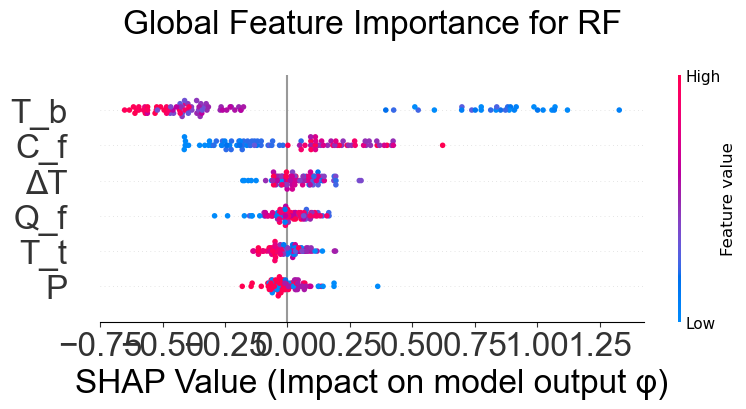

In [7]:

# 4.1 总体特征重要性图 (Summary Plot / Beeswarm Plot)
print("\n--- 正在绘制图1：总体特征重要性图 (Summary Plot) ---")
print("该图展示了哪些特征最重要，以及它们如何影响模型预测。")
plt.figure(figsize=(14, 8))
# 注意：shap_values是解释标准化后的数据，但第二个参数我们传入原始的X
# 这样图上的颜色和数据点就能反映原始特征值的大小，更具可解释性
shap.summary_plot(shap_values, X, plot_type="dot", show=False, color_bar=True,  plot_size=0.45)
plt.title('Global Feature Importance for RF', fontsize=24, pad=30, fontfamily='Arial')
plt.xlabel("SHAP Value (Impact on model output φ)", fontsize=24, fontfamily='Arial')
plt.yticks(fontsize=24, fontfamily='Arial')
plt.xticks(fontsize=24, fontfamily='Arial')
plt.tight_layout()
plt.savefig("shap_summary_plot_y2.pdf", format="pdf", dpi=330)
plt.show()


--- 正在绘制图2：平均特征重要性图 (Bar Plot) ---
该图更直观地展示了各特征对预测的平均影响大小。


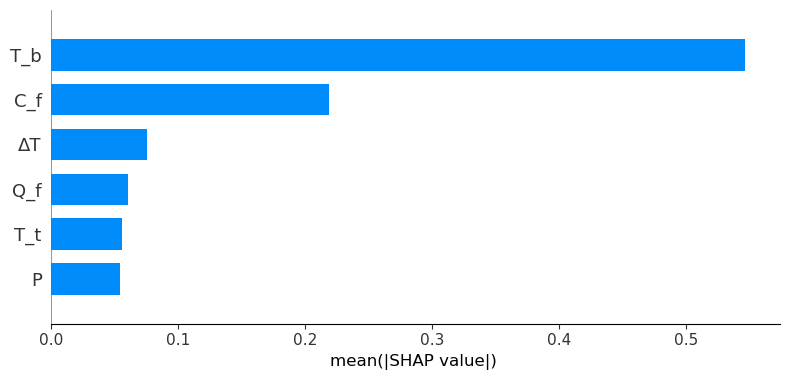

In [12]:
# 4.2 特征重要性排序图 (Bar Plot)
print("\n--- 正在绘制图2：平均特征重要性图 (Bar Plot) ---")
print("该图更直观地展示了各特征对预测的平均影响大小。")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.xlabel("mean(|SHAP value|) ", fontsize=12)
plt.tight_layout()
plt.show()



In [9]:
raw_shap_values = shap_values
feature_columns = X.columns if isinstance(X, pd.DataFrame) else feature_names
# 计算每个特征的平均绝对 SHAP 值 (Mean Absolute SHAP Value)
mean_abs_shap = np.abs(raw_shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Mean_Absolute_SHAP_Value': mean_abs_shap
})
importance_df = importance_df.sort_values(
    by='Mean_Absolute_SHAP_Value', 
    ascending=False
).reset_index(drop=True)
print("特征重要性排序图 (Bar Plot) 的数据：")
print(importance_df.head(6).to_string(index=True, float_format=lambda x: f"{x:.4f}"))

特征重要性排序图 (Bar Plot) 的数据：
  Feature  Mean_Absolute_SHAP_Value
0     T_b                    0.5465
1     C_f                    0.2184
2      ΔT                    0.0752
3     Q_f                    0.0602
4     T_t                    0.0557
5       P                    0.0537



--- 正在绘制图3：各特征的依赖图 (Dependence Plots) ---
该系列图展示了单个特征如何具体影响模型的输出，并能揭示交互效应。


<Figure size 1200x800 with 0 Axes>

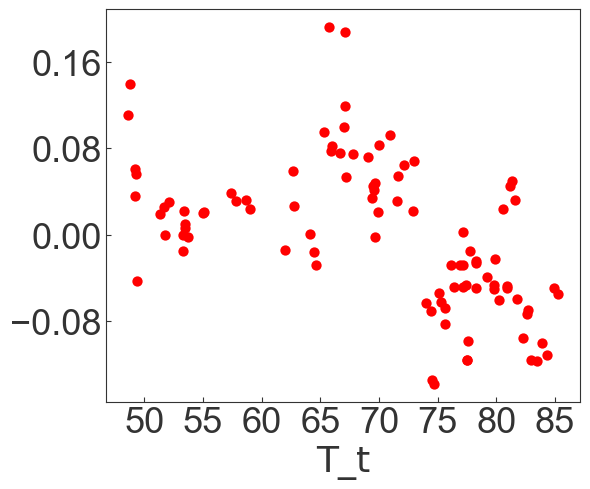

<Figure size 1200x800 with 0 Axes>

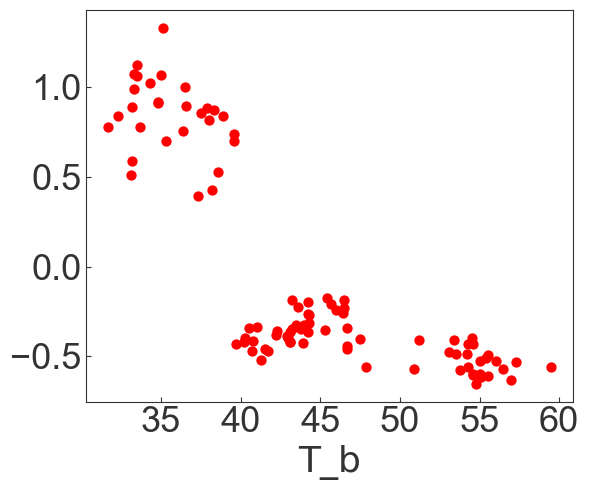

<Figure size 1200x800 with 0 Axes>

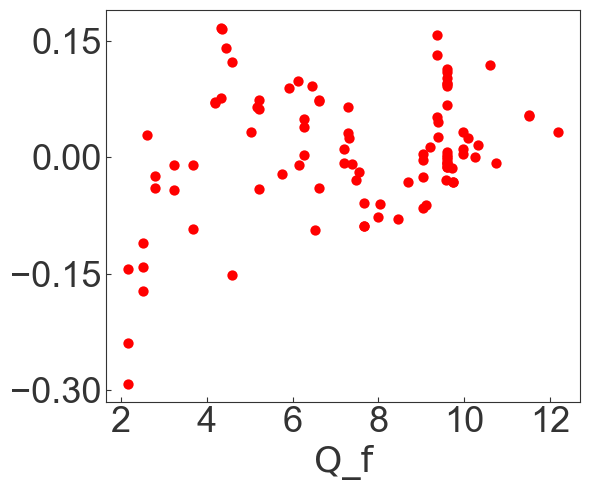

<Figure size 1200x800 with 0 Axes>

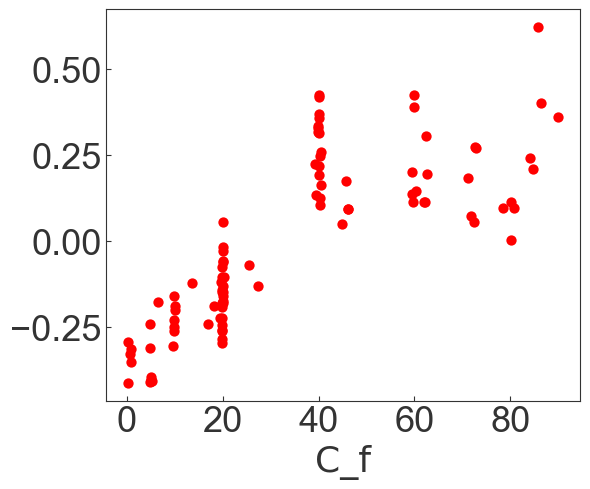

<Figure size 1200x800 with 0 Axes>

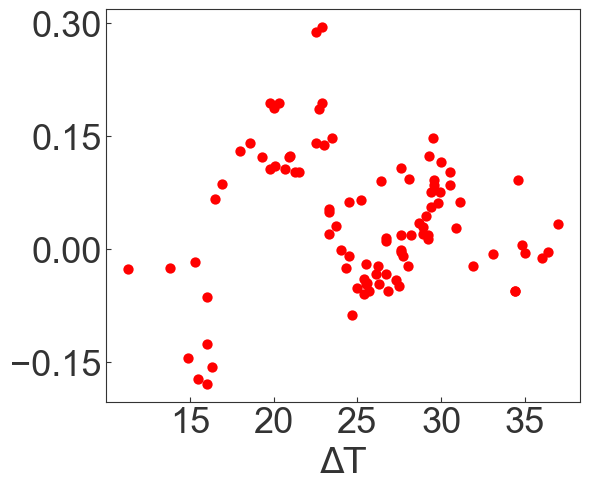

<Figure size 1200x800 with 0 Axes>

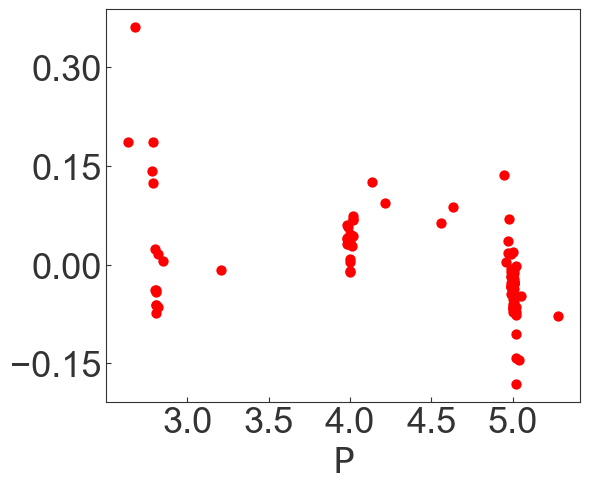

📊 总样本数量 (散点个数): 95 个


In [20]:
from matplotlib.ticker import MaxNLocator

# 4.3 特征依赖图 (Dependence Plots)
print("\n--- 正在绘制图3：各特征的依赖图 (Dependence Plots) ---")
print("该系列图展示了单个特征如何具体影响模型的输出，并能揭示交互效应。")
for feature in feature_names:
    plt.figure(figsize=(12, 8)) # 为每个依赖图创建一个新的图形窗口
    shap.dependence_plot(
        feature, 
        shap_values, 
        X, 
        interaction_index=None,
        dot_size=55,   
        color='red',          
        show=False
    )
    
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.tick_params(
        axis='y',          # 针对 Y 轴（即左轴）
        direction='in'     # 设置刻度线方向朝内
	)
    ax.tick_params(
        axis='x',
        labeltop=False,
        direction='in'     
    )
    plt.ylabel(f"", fontsize=26)
    plt.xlabel(f"{feature}", fontsize=26)
    plt.yticks(fontsize=26, fontfamily='Arial')
    plt.xticks(fontsize=26, fontfamily='Arial')
    plt.tight_layout()
    plt.grid(False)
    plt.savefig(f"E:/20250515-优化工艺参数-代码和数据/画图/SI/209shap_dependence_y2_{feature}.tiff", format="tiff", dpi=300)
    plt.show()


total_points = len(X)
print(f"📊 总样本数量 (散点个数): {total_points} 个")


--- 正在绘制图4：双变量部分依赖图 (2D Contour Plots) ---

正在计算和绘制 'T_t' 与 'T_b' 的交互图...


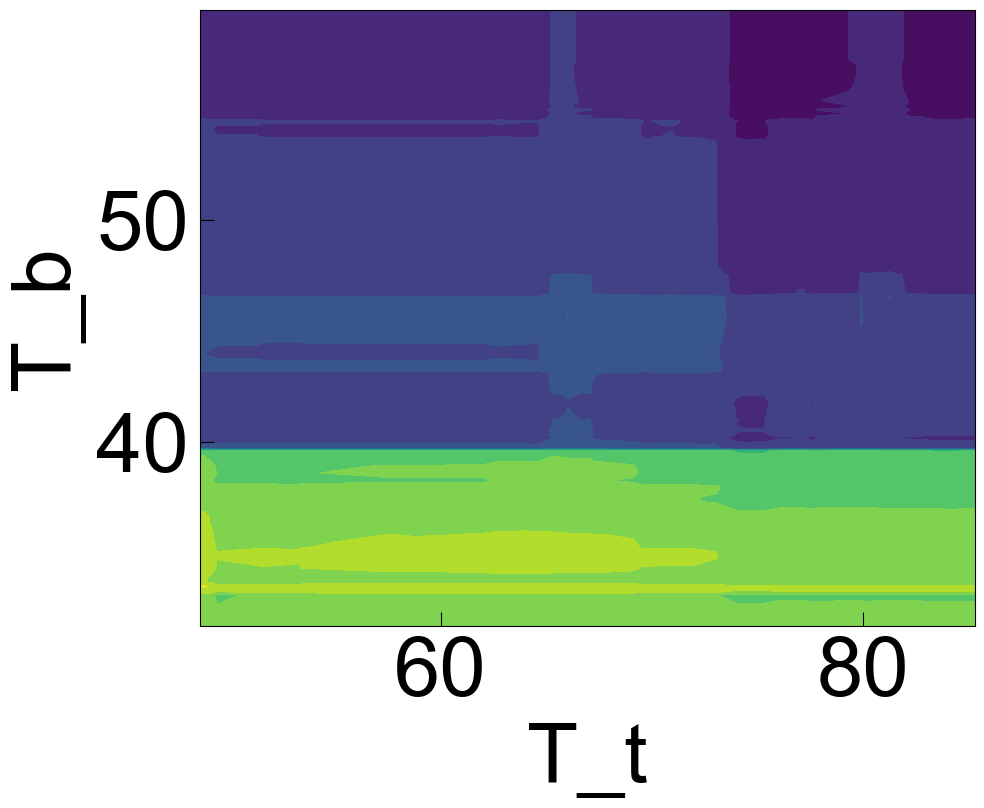


正在计算和绘制 'T_t' 与 'Q_f' 的交互图...


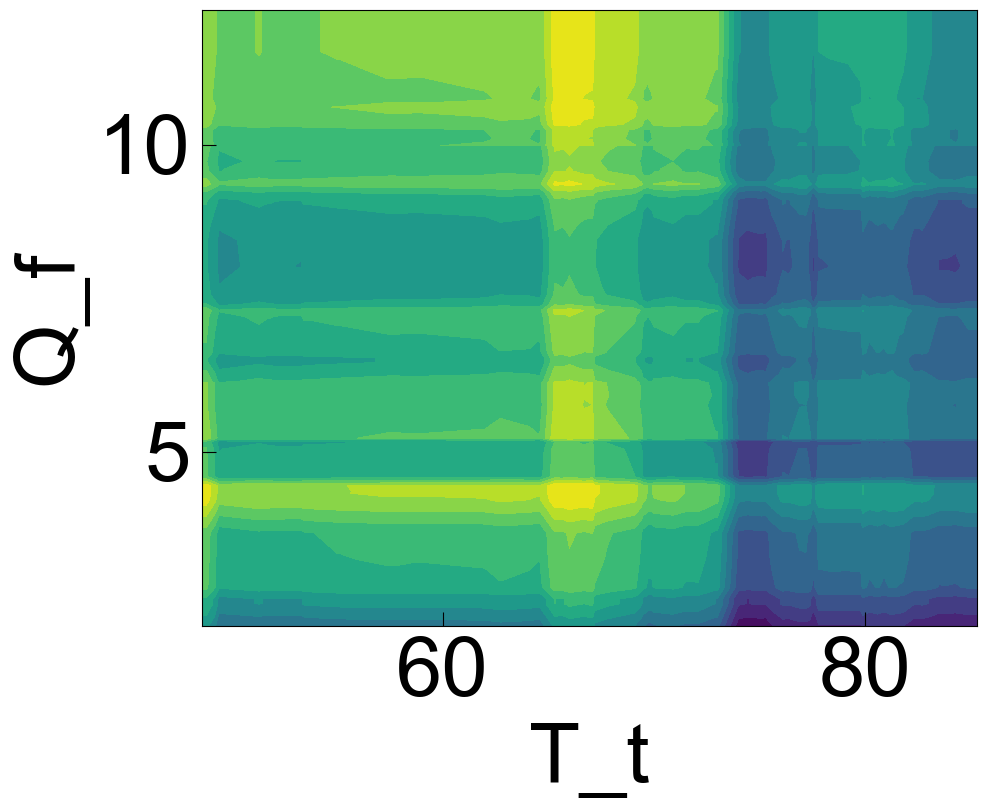


正在计算和绘制 'T_t' 与 'C_f' 的交互图...


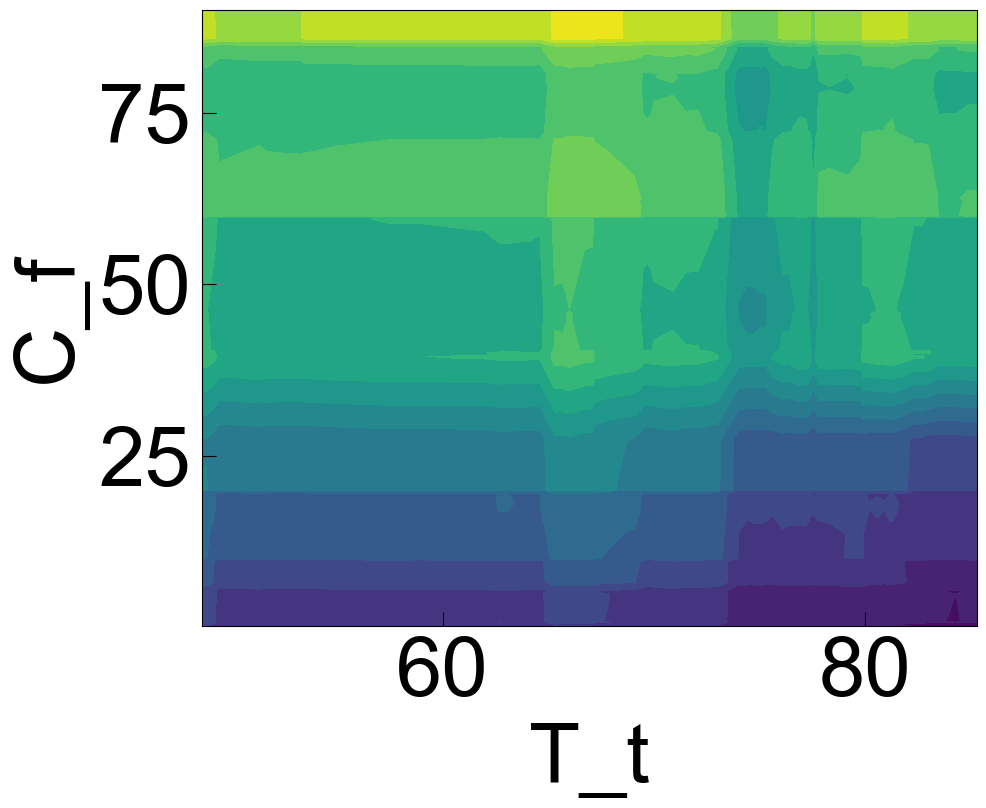


正在计算和绘制 'T_t' 与 'ΔT' 的交互图...


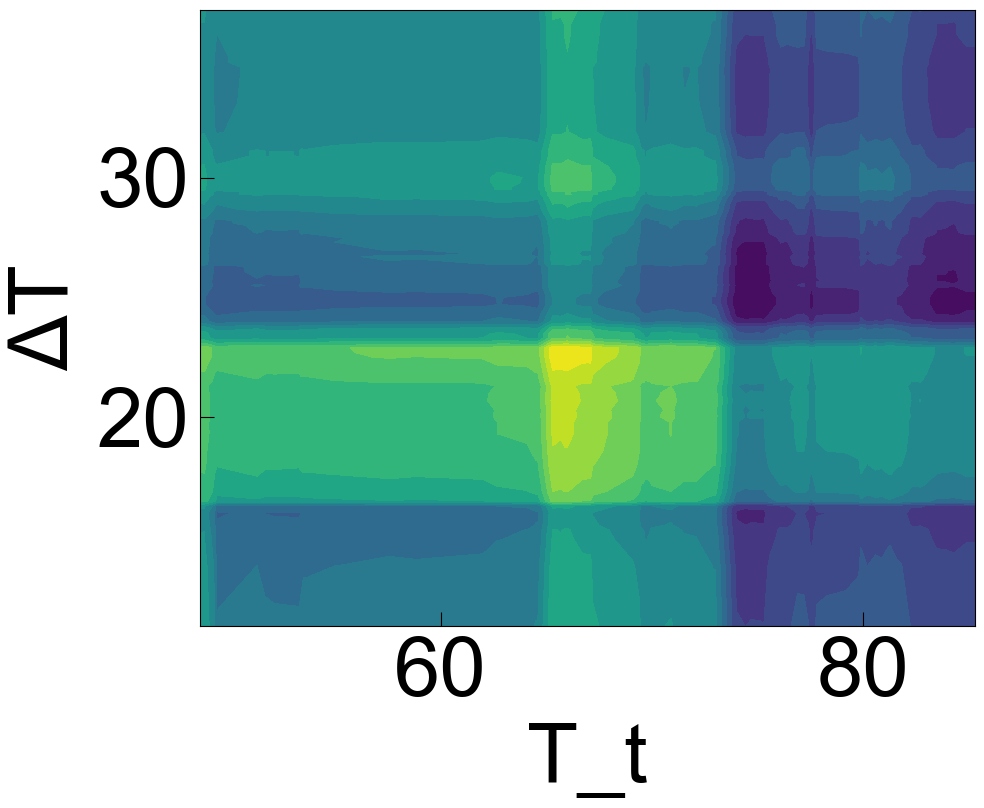


正在计算和绘制 'T_t' 与 'P' 的交互图...


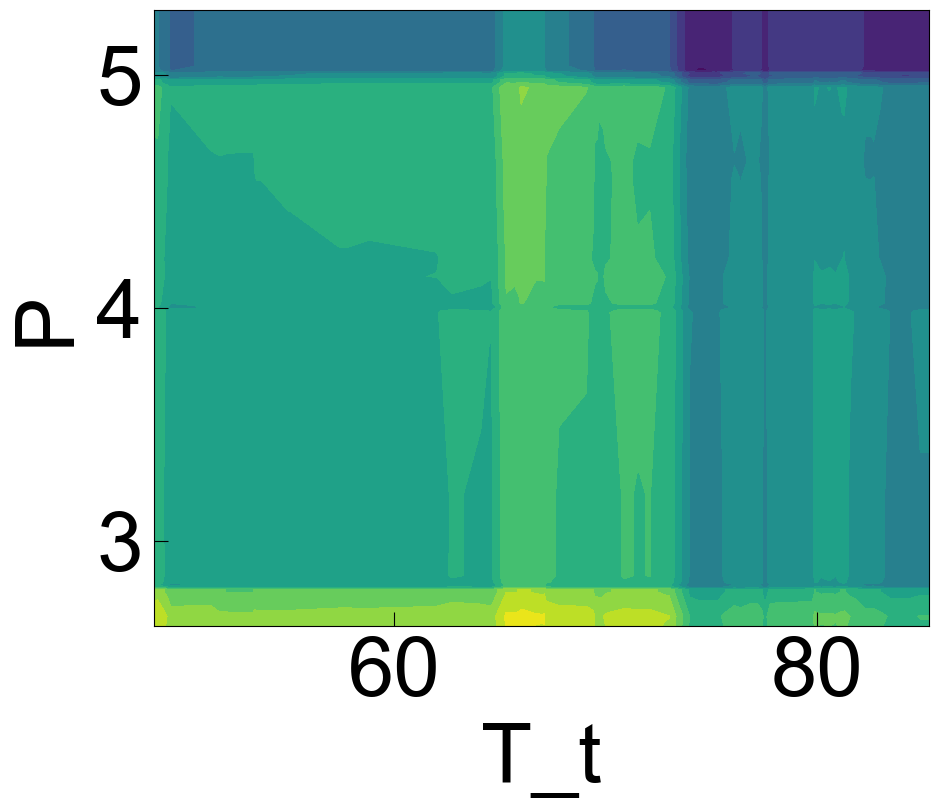


正在计算和绘制 'T_b' 与 'Q_f' 的交互图...


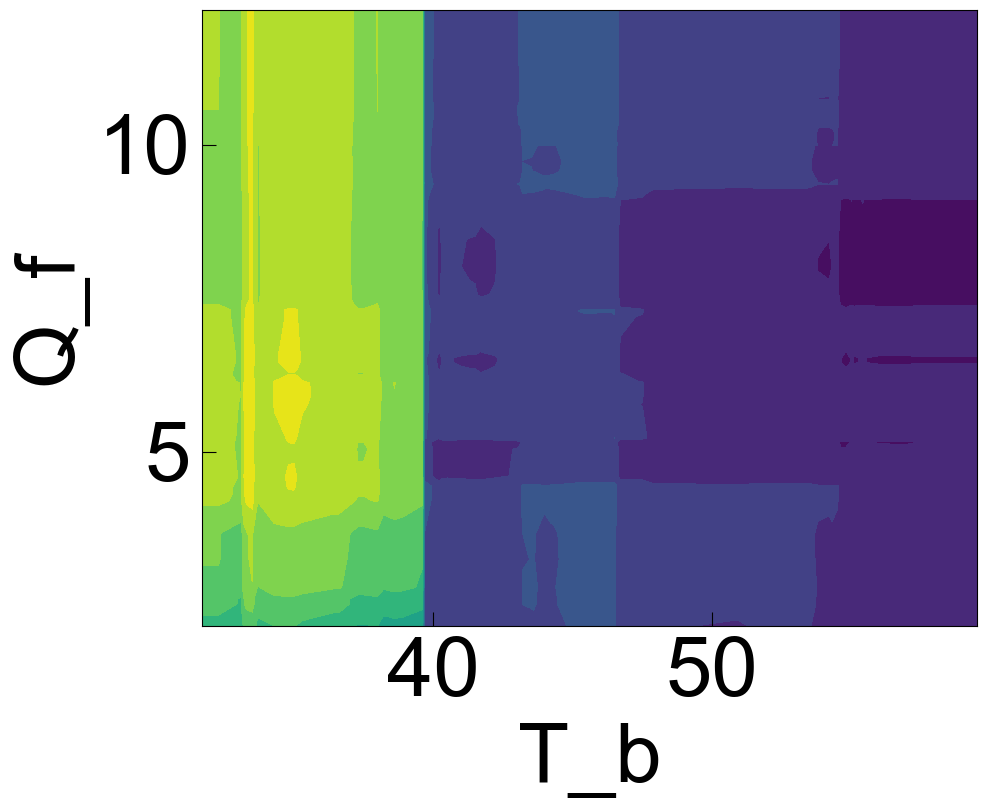


正在计算和绘制 'T_b' 与 'C_f' 的交互图...


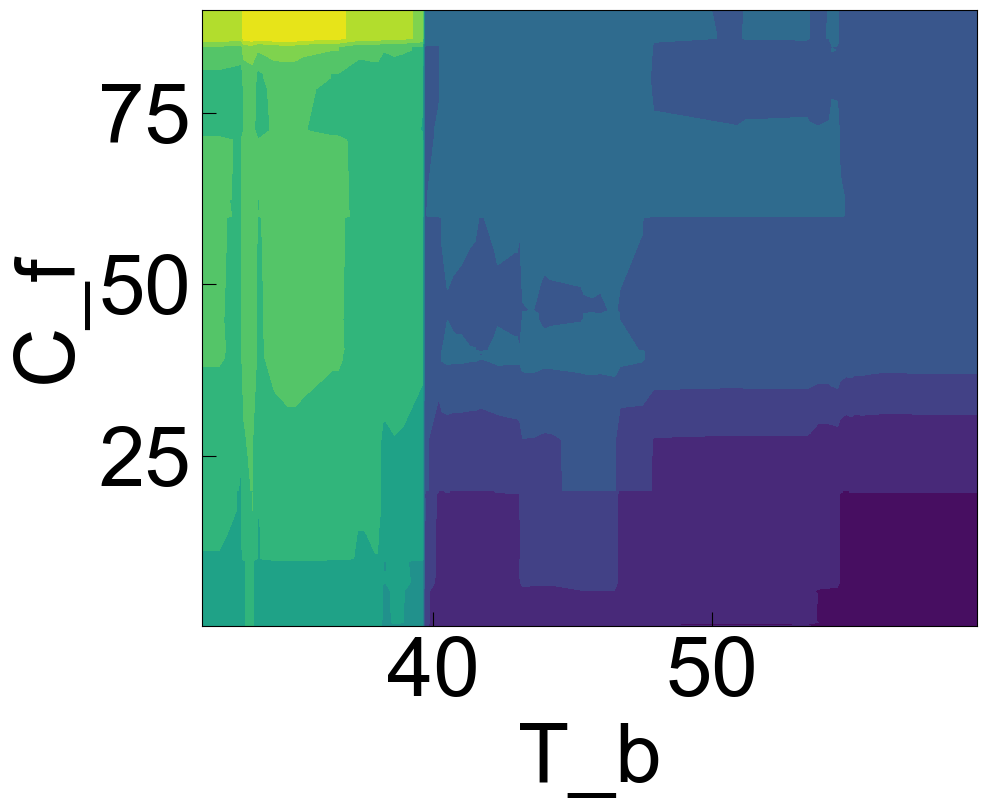


正在计算和绘制 'T_b' 与 'ΔT' 的交互图...


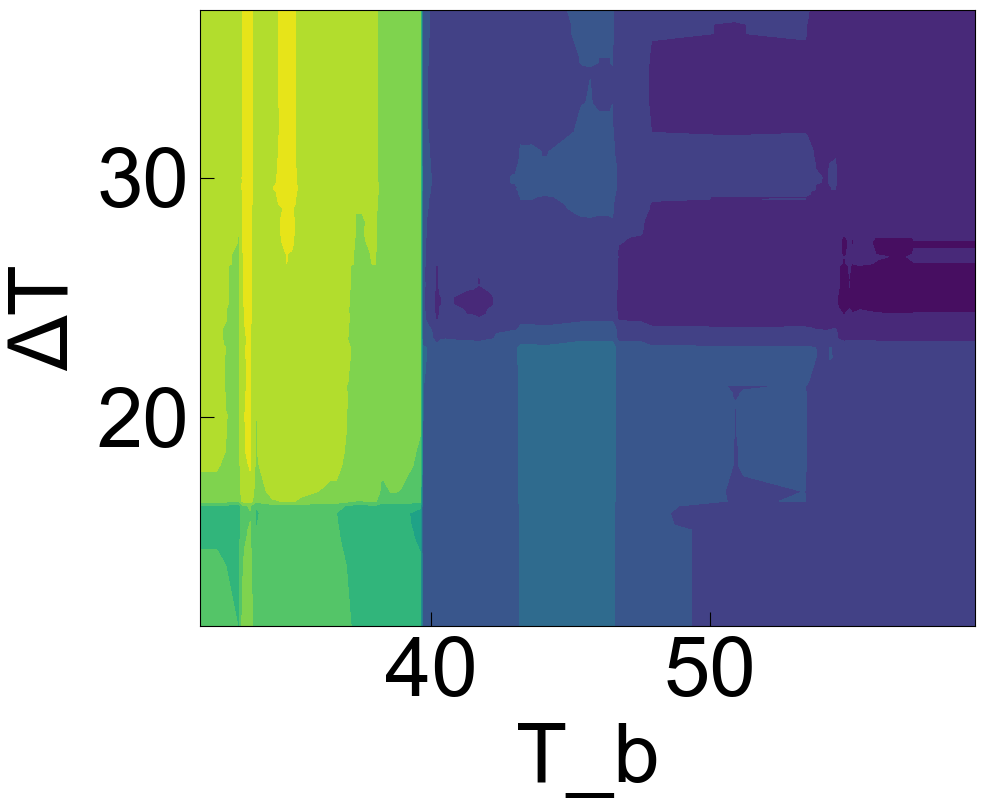


正在计算和绘制 'T_b' 与 'P' 的交互图...


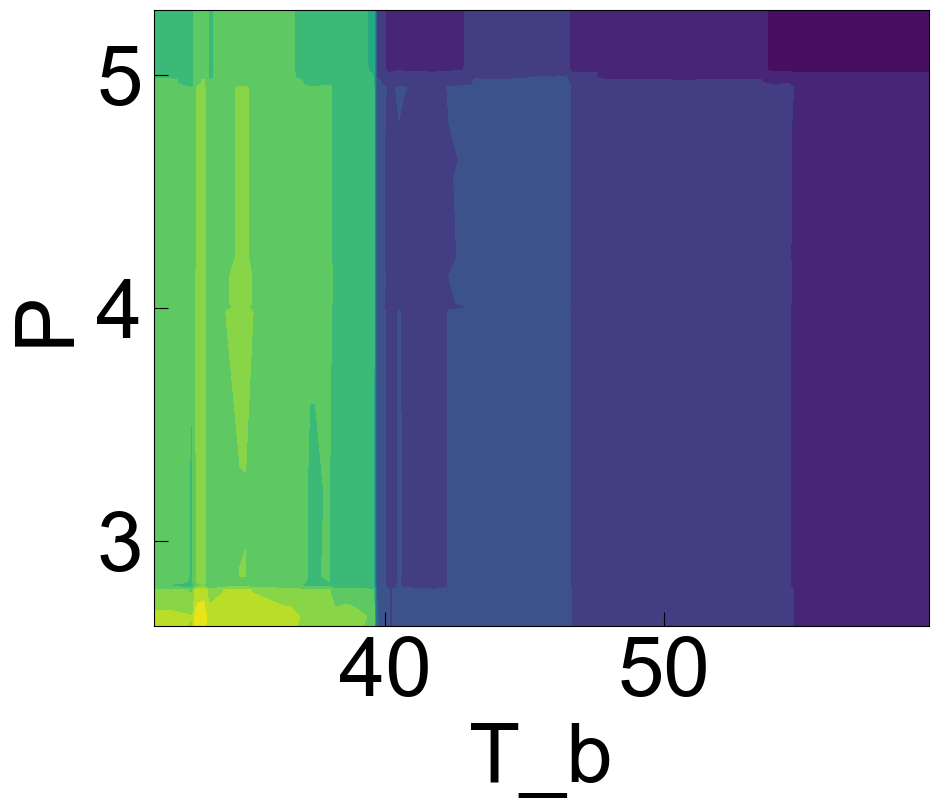


正在计算和绘制 'Q_f' 与 'C_f' 的交互图...


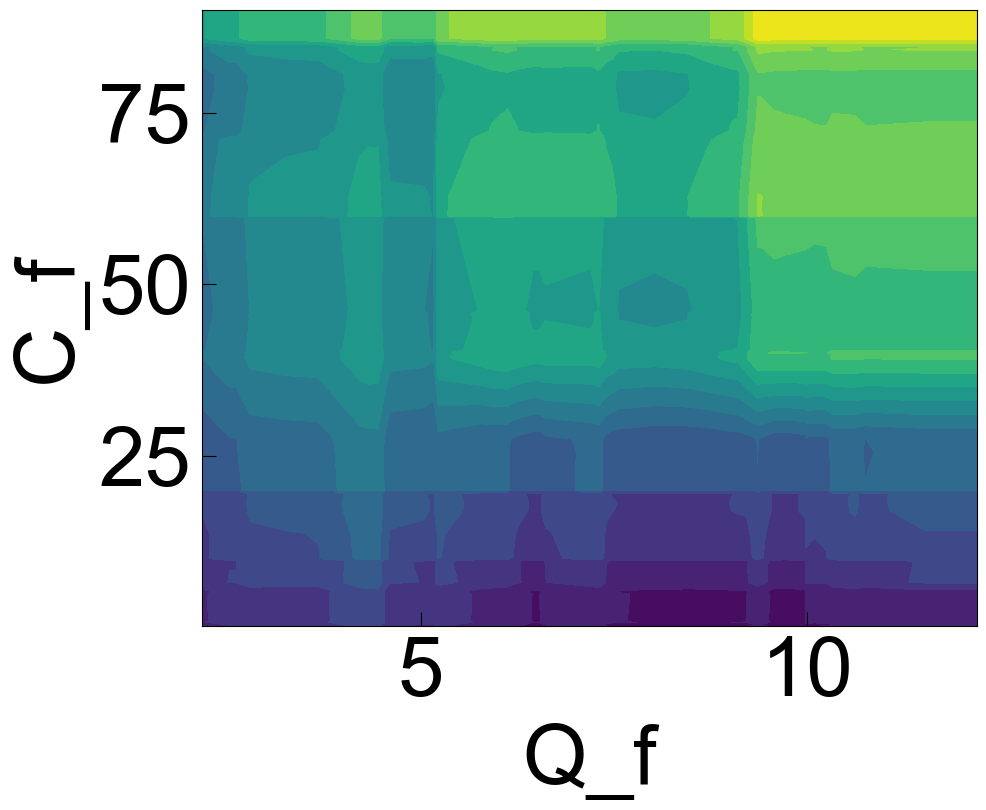


正在计算和绘制 'Q_f' 与 'ΔT' 的交互图...


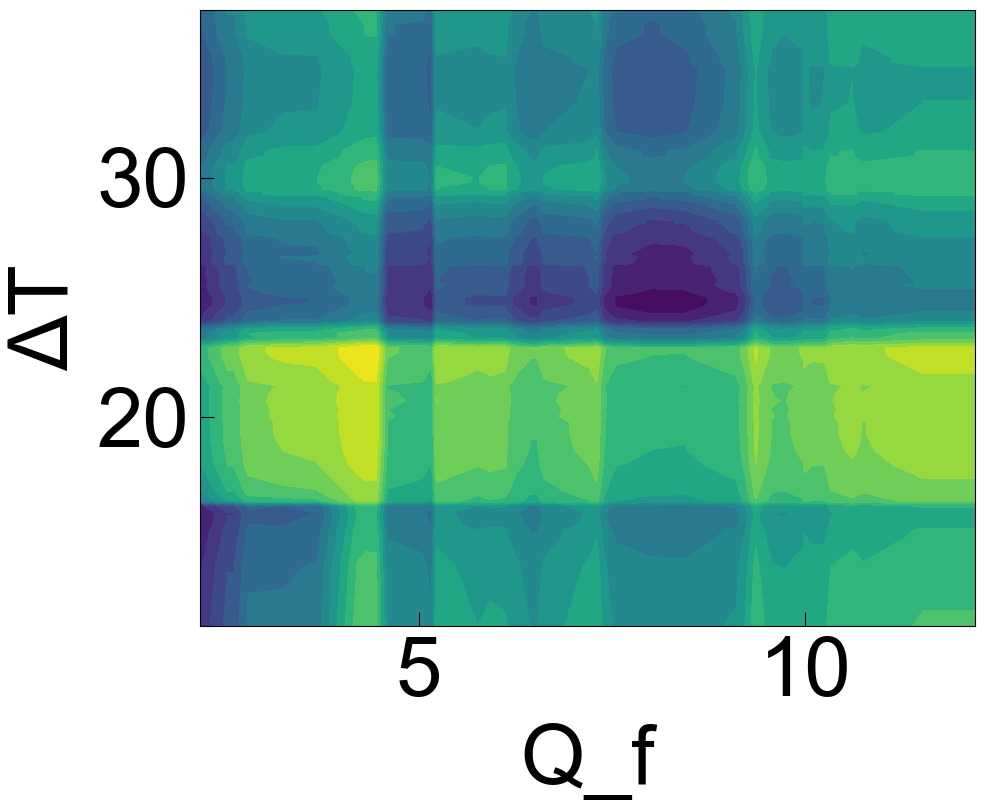


正在计算和绘制 'Q_f' 与 'P' 的交互图...


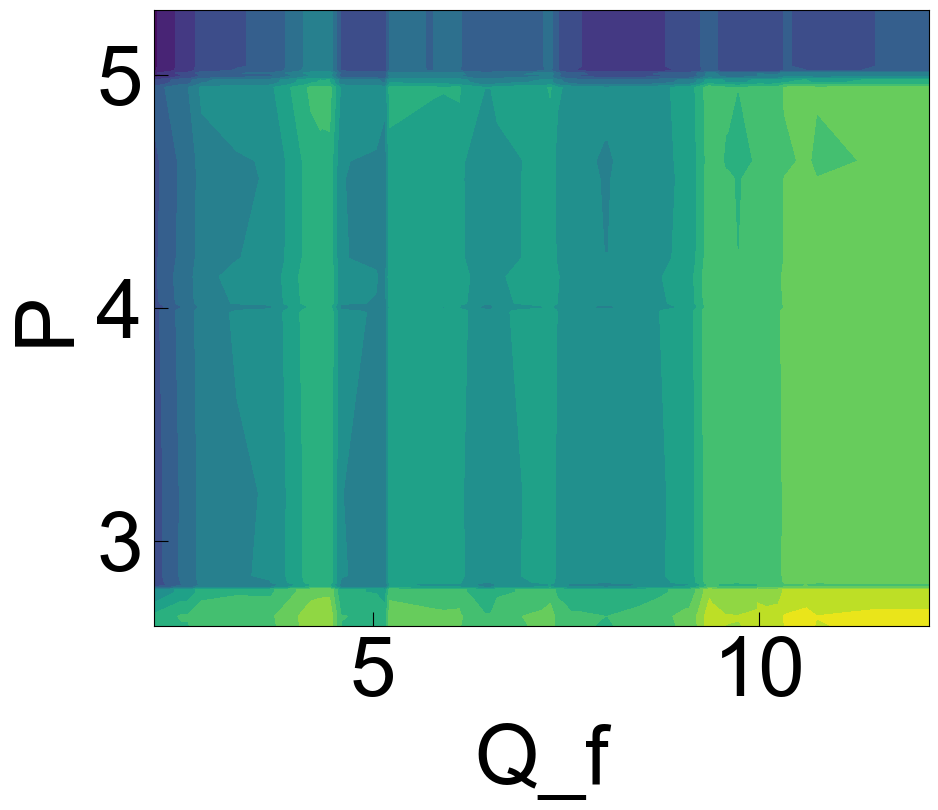


正在计算和绘制 'C_f' 与 'ΔT' 的交互图...


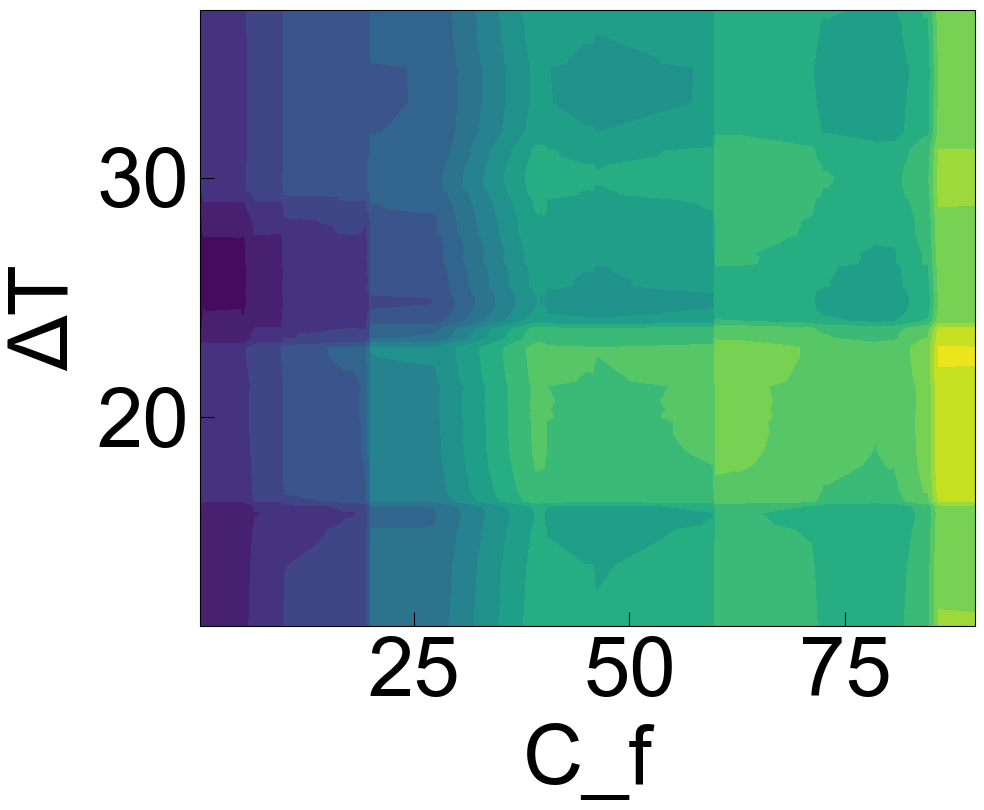


正在计算和绘制 'C_f' 与 'P' 的交互图...


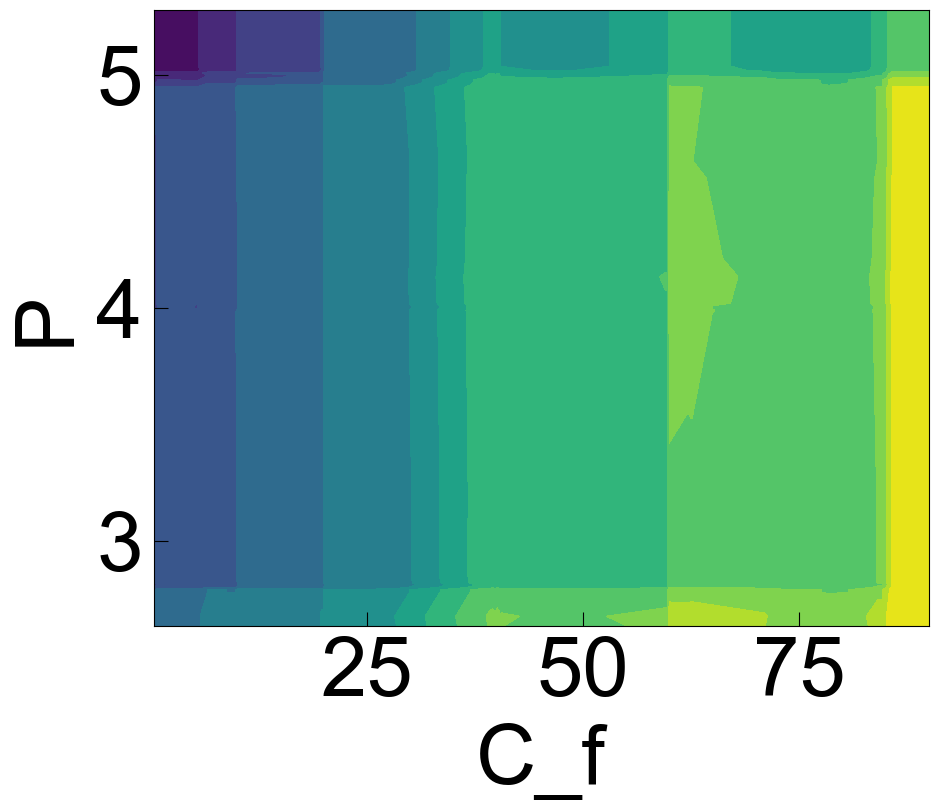


正在计算和绘制 'ΔT' 与 'P' 的交互图...


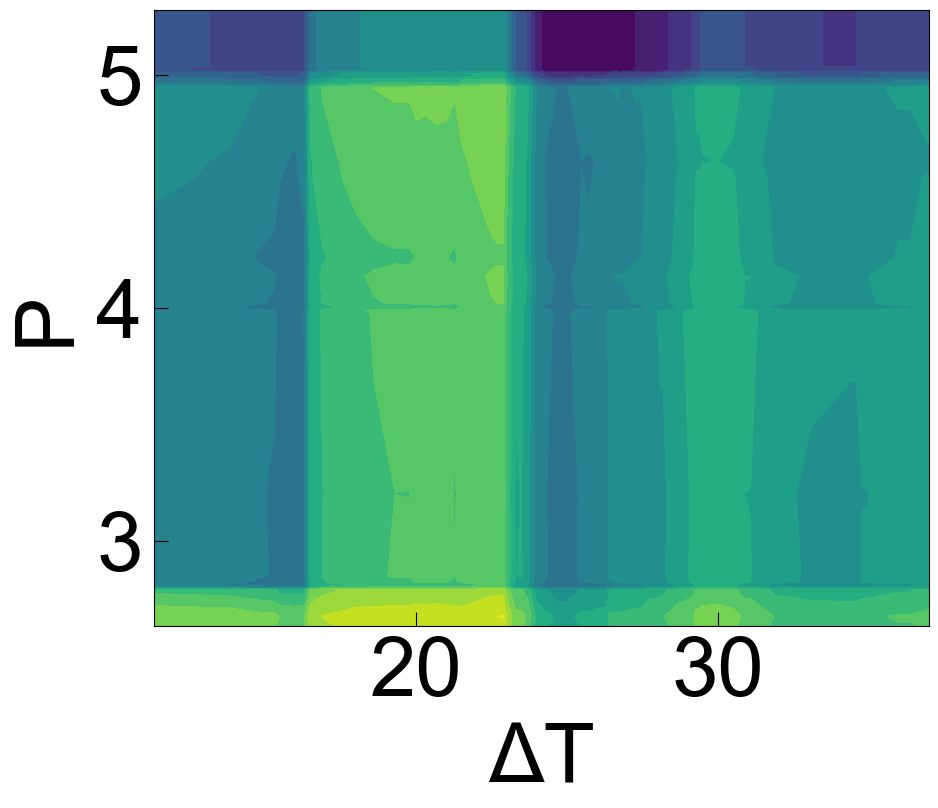

In [28]:
print("\n--- 正在绘制图4：双变量部分依赖图 (2D Contour Plots) ---")
from itertools import combinations
from sklearn.inspection import partial_dependence
# 生成所有特征的两两组合
feature_pairs = list(combinations(feature_names, 2))

# 遍历每个特征对
for pair in feature_pairs:
    feature1, feature2 = pair
    print(f"\n正在计算和绘制 '{feature1}' 与 '{feature2}' 的交互图...")
    
    # 使用 partial_dependence 函数计算 PDP 数据
    # 我们在标准化的训练集上进行计算，因为模型是在此基础上训练的
    pdp_results = partial_dependence(
        best_model,
        X_scaled_df, # 使用DataFrame以支持字符串特征名
        features=[feature1, feature2],
        kind='average',
        grid_resolution=400 # 增加网格密度以获得更平滑的等高线
    )

    # 提取计算结果
    Z_scaled = pdp_results['average'][0]
    grid_values = pdp_results['grid_values']
    
    # 将预测结果Z反标准化到原始尺度
    Z_orig = y_scaler.inverse_transform(Z_scaled.reshape(-1, 1)).reshape(Z_scaled.shape)
    
    # 创建二维网格用于反标准化坐标轴
    XX, YY = np.meshgrid(grid_values[0], grid_values[1])
    grid_nodes_scaled = np.c_[XX.ravel(), YY.ravel()]
    
    # 反标准化坐标轴的技巧
    background_board = np.tile(x_scaler.mean_, (grid_nodes_scaled.shape[0], 1))
    f1_idx = feature_names.index(feature1)
    f2_idx = feature_names.index(feature2)
    background_board[:, f1_idx] = grid_nodes_scaled[:, 0]
    background_board[:, f2_idx] = grid_nodes_scaled[:, 1]
    grid_nodes_orig = x_scaler.inverse_transform(background_board)
    
    # 提取反标准化后的坐标轴
    X_axis = grid_nodes_orig[:, f1_idx].reshape(XX.shape)
    Y_axis = grid_nodes_orig[:, f2_idx].reshape(YY.shape)
    
    # --- 【修改】使用 Matplotlib 创建 2D 等高线图 ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 绘制填充等高线 (contourf)，20个水平层级
    contour = ax.contourf(X_axis, Y_axis, Z_orig.T, 15, cmap='viridis')
 
    # 添加颜色条，显示预测的PR值
    #cbar = fig.colorbar(contour, ax=ax, label='Predicted PR')
    #cbar.set_label('Predicted PR Value', fontsize=22, fontfamily='Arial') 
    
    # 修改颜色条刻度 (tick) 数字的字体大小
    #cbar.ax.tick_params(labelsize=16)
    
    # 绘制等高线线条 (contour)
    #contour_lines = ax.contour(X_axis, Y_axis, Z_orig.T, 15, linewidths=0.5)
    
    # 在等高线上添加数值标签
    #ax.clabel(contour_lines, inline=False, fontsize=12, fmt='%.2f')
    
    # 在图上叠加实际训练数据点的散点图，以显示数据分布
    # 只绘制与当前特征对相关的两列数据
    #ax.scatter(X_train[feature1], X_train[feature2], c='red', s=10, alpha=0.5, label='Training Data Points')
    
    # 设置刻度标签字体
    ax.tick_params(axis='both', which='major', direction='in', length=10, labelsize=60, pad=8)
    for label in ax.get_xticklabels():
        label.set_fontfamily('Arial')
    for label in ax.get_yticklabels():
        label.set_fontfamily('Arial')
    
    # 设置图表标题和坐标轴标签
    file_name = f"E:/20250515-优化工艺参数-代码和数据/画图/SI/209PDP_y2_{feature1}_{feature2}.pdf"
    #ax.set_title(f'Partial Dependence: {feature1} & {feature2}', fontsize=22, pad=20)
    ax.set_xlabel(feature1, fontfamily='Arial', fontsize=60, labelpad=8)
    ax.set_ylabel(feature2, fontsize=60, fontfamily='Arial',labelpad=8)
    plt.savefig(file_name, format="PDF", dpi=1200, bbox_inches='tight')
    plt.show()


In [ ]:
plotting_config = {
    ('T_t', 'T_b'): {
        # 1. 显式的 levels 列表 (用于 contourf 和 contour)
        'levels': [0.12, 0.15, 0.18, 0.21, 0.24, 0.27, 0.30],
        # 2. 手动指定标签位置 (X_axis, Y_axis)
        'manual_labels': [
            (60, 36),  # 较低值区域
            (75, 52),  # 较高值区域
            (55, 45),  # 敏感区域
            (70, 40.5) # 密集边界附近
        ],
        # 3. 标签字体大小优化
        'label_fontsize': 10 
    },
    
    # 示例配置 2：假设您还有另一对特征 (FeatA, FeatB)
    ('FeatA', 'FeatB'): {
        'levels': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'manual_labels': [
            (10, 200),
            (50, 150),
        ],
        'label_fontsize': 12
    },
}

: 

: 

In [ ]:
# --- 6. 将所有模型性能结果保存至Excel ---
print(f"\n{'='*25} 生成性能报告 {'='*25}")

# 导入pandas库，它是处理表格数据的核心工具
import pandas as pd

# 检查 model_performance_results 是否有内容
if model_performance_results:
    # 1. 将存储结果的字典转换为pandas DataFrame
    # orient='index' 会让字典的键（模型名称）成为DataFrame的行索引
    performance_df = pd.DataFrame.from_dict(model_performance_results, orient='index')

    # 2. 调整列的顺序，使其更符合报告的阅读习惯
    column_order = [
        'train_r2', 'test_r2', 
        'train_rmse', 'test_rmse', 
        'train_mae', 'test_mae'
    ]
    performance_df = performance_df[column_order]

    # 3. (可选，但建议) 重命名列名，使其更具可读性
    performance_df.rename(columns={
        'train_r2': 'R² (Train)', 'test_r2': 'R² (Test)',
        'train_rmse': 'RMSE (Train)', 'test_rmse': 'RMSE (Test)',
        'train_mae': 'MAE (Train)', 'test_mae': 'MAE (Test)'
    }, inplace=True)

    # 4. (可选，但建议) 为行索引命名
    performance_df.index.name = 'Best Model'

    # 5. 定义要保存的Excel文件名
    output_filename = 'model_performance_results_2.xlsx'

    # 6. 将DataFrame保存为Excel文件
    # index=True确保模型名称（行索引）也被写入文件
    performance_df.to_excel(output_filename, index=True)

    print(f"所有模型的性能对比已成功保存至Excel文件: '{output_filename}'")
    
    # 打印最终的DataFrame，以便在控制台预览
    print("\n--- 性能对比总表 ---")
    print(performance_df)

else:
    print("没有可供保存的性能结果。")


========================= 生成性能报告 =========================
所有模型的性能对比已成功保存至Excel文件: '22222.xlsx'

--- 性能对比总表 ---
              R² (Train)  R² (Test)  RMSE (Train)  RMSE (Test)  MAE (Train)  \
Best Model                                                                    
Ridge           0.451838   0.628650      0.070252     0.055092     0.056608   
DecisionTree    0.650309   0.601033      0.056111     0.057104     0.041910   
RandomForest    0.907507   0.737724      0.028858     0.046300     0.021822   
ExtraTrees      0.865294   0.409923      0.034826     0.069447     0.027554   
SVR             0.454302   0.637614      0.070094     0.054423     0.055129   
XGBoost         0.816904   0.711187      0.040602     0.048586     0.032816   
LightGBM        0.598076   0.698099      0.060156     0.049674     0.047131   
CatBoost        0.671252   0.456176      0.054405     0.066670     0.044352   
MLP             0.358070   0.468419      0.076024     0.065915     0.064400   

              MAE

: 

: 


--- 正在绘制图5：个体条件期望图 (ICE Plots) ---
该图展示了单个样本的预测值随特征变化的情况，揭示个体层面的特征影响。
注意：计算过程可能需要几分钟，请耐心等待...

正在绘制特征 'T_t' 的ICE图...
正在绘制特征 'T_t' 的中心化ICE图...


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\m

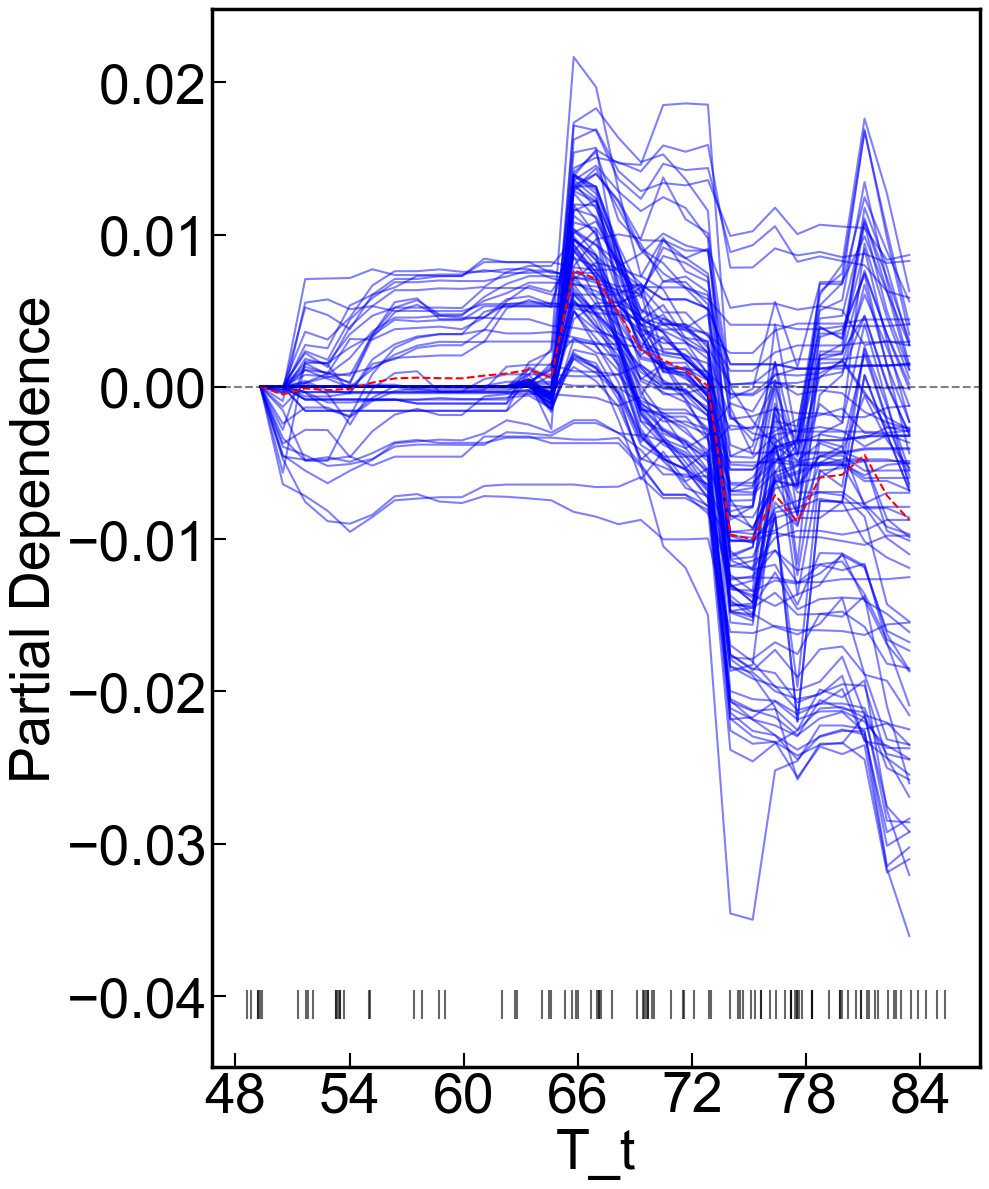


正在绘制特征 'T_b' 的ICE图...
正在绘制特征 'T_b' 的中心化ICE图...


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\m

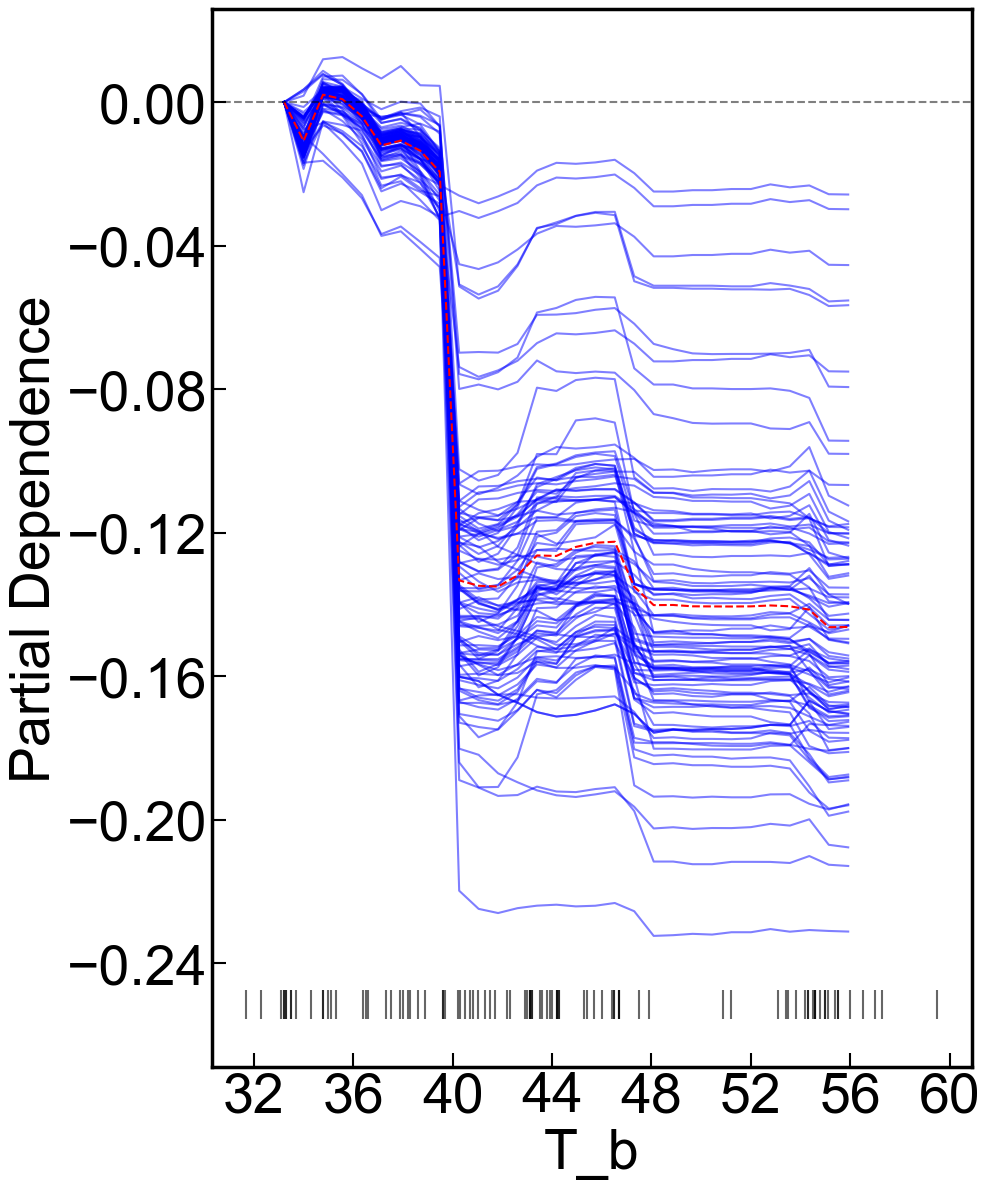


正在绘制特征 'Q_f' 的ICE图...
正在绘制特征 'Q_f' 的中心化ICE图...


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\m

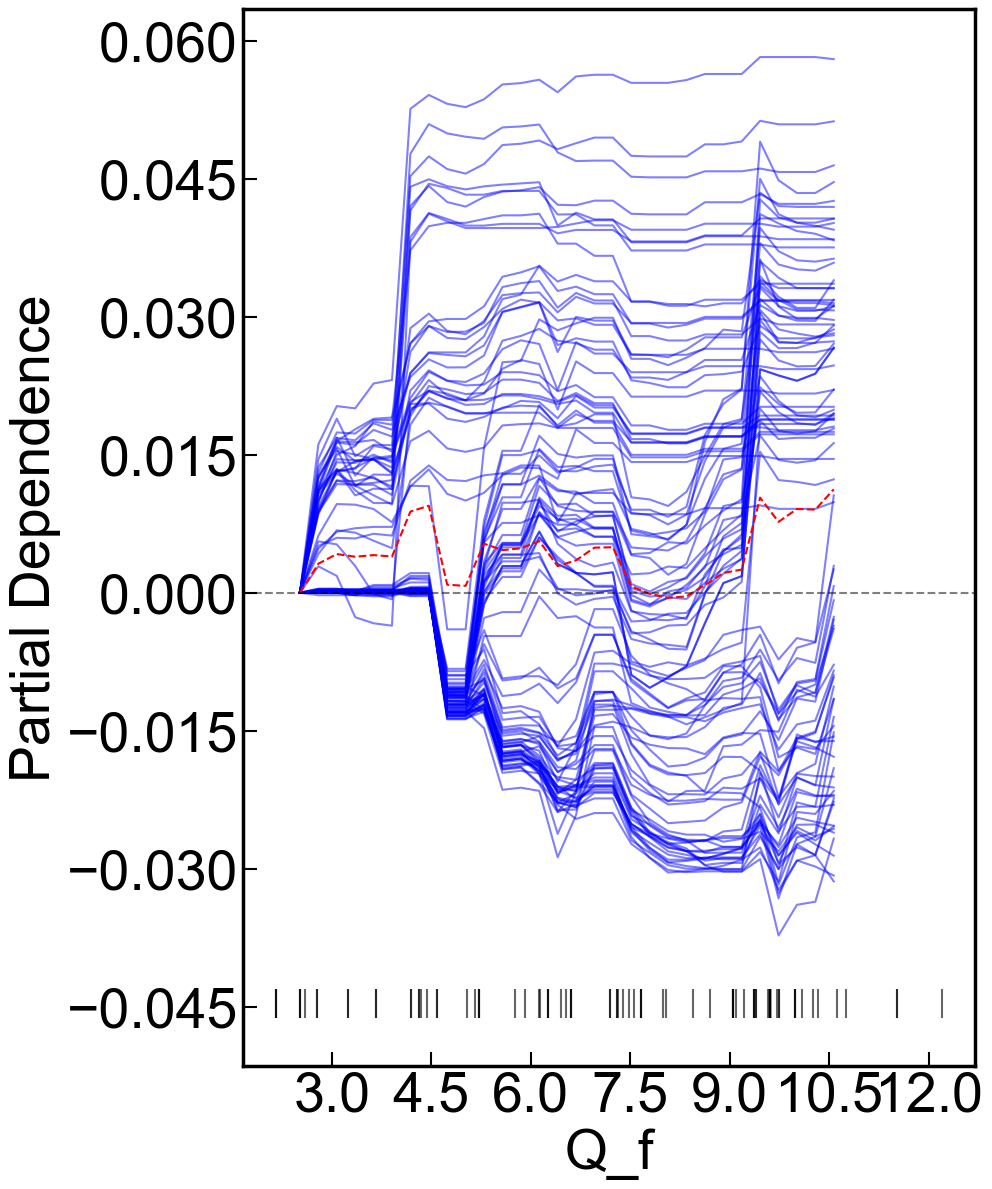


正在绘制特征 'C_f' 的ICE图...
正在绘制特征 'C_f' 的中心化ICE图...


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\m

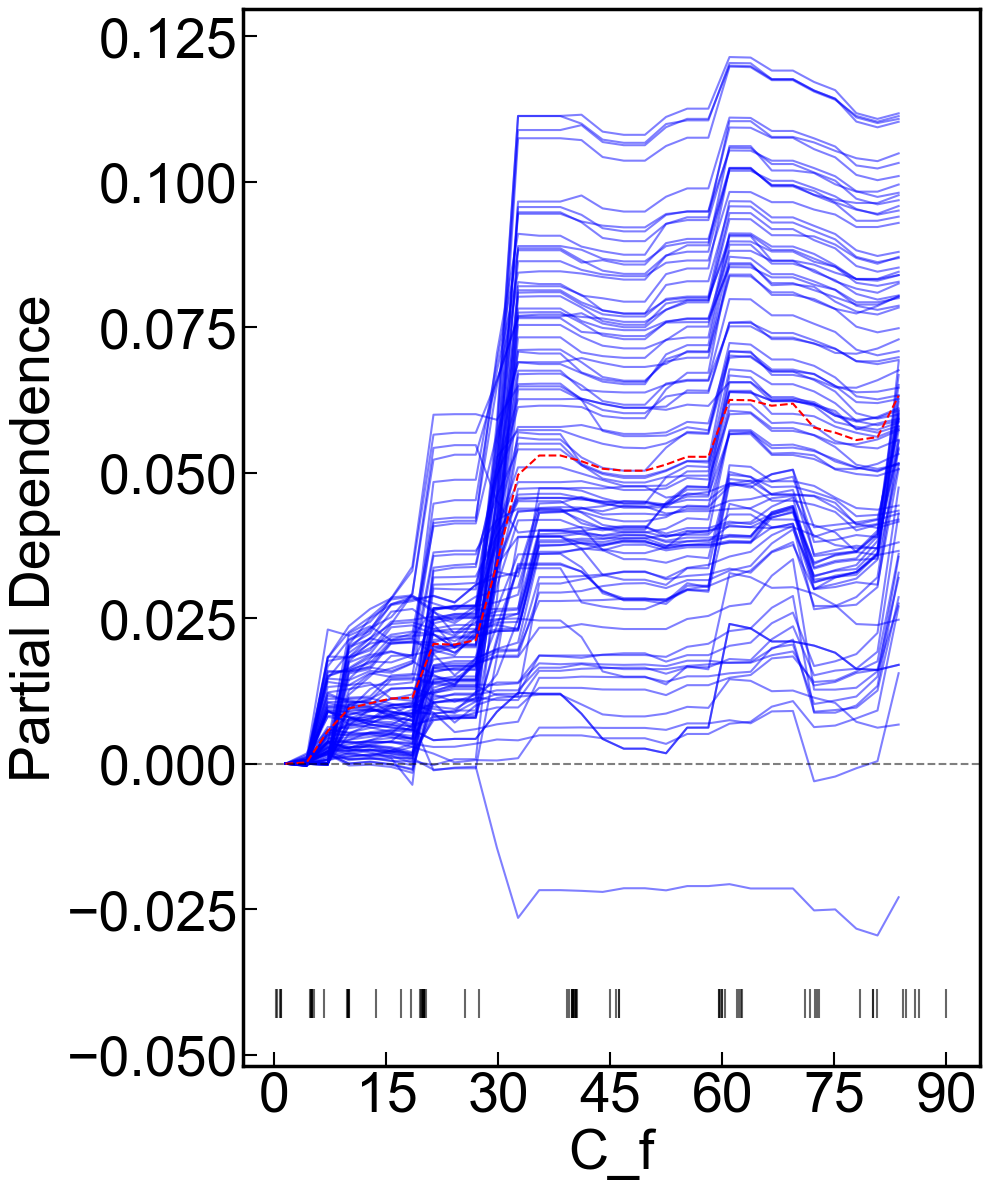


正在绘制特征 'ΔT' 的ICE图...
正在绘制特征 'ΔT' 的中心化ICE图...


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\m

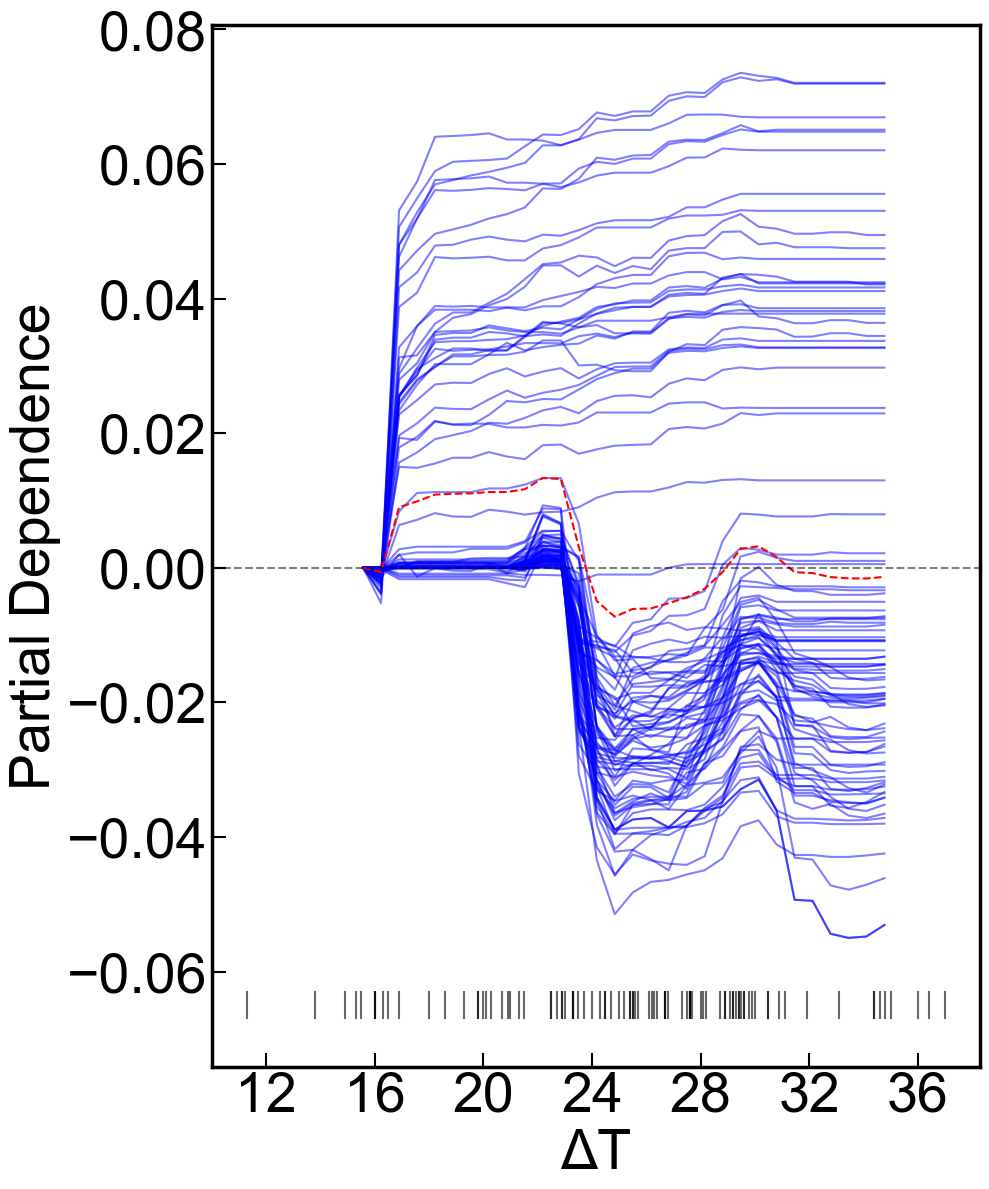


正在绘制特征 'P' 的ICE图...
正在绘制特征 'P' 的中心化ICE图...


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\m

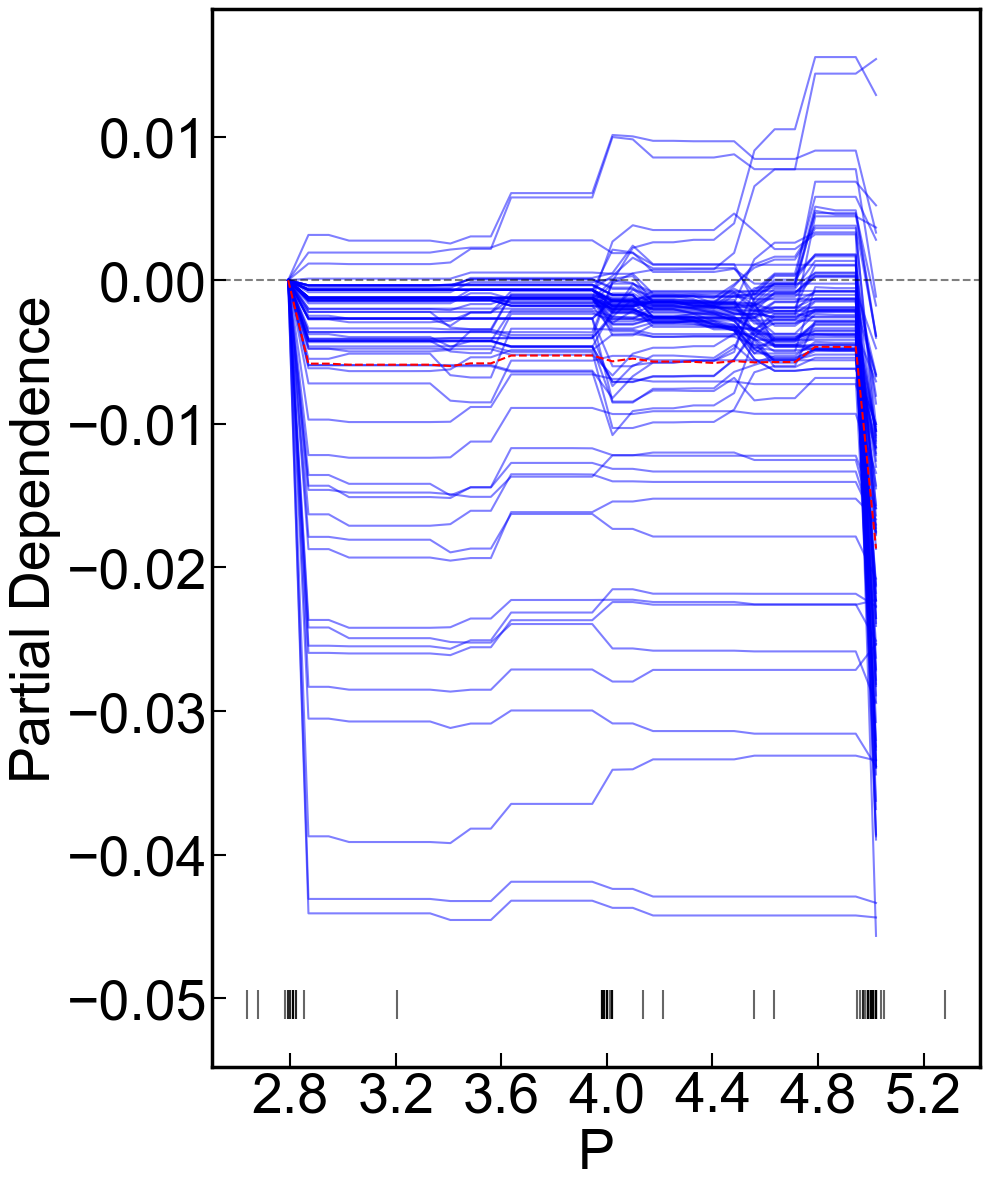

In [27]:
# --- 6. 绘制个体条件期望图 (Individual Conditional Expectation Plots) ---
print("\n--- 正在绘制图5：个体条件期望图 (ICE Plots) ---")
print("该图展示了单个样本的预测值随特征变化的情况，揭示个体层面的特征影响。")
print("注意：计算过程可能需要几分钟，请耐心等待...")

from sklearn.inspection import partial_dependence
from matplotlib.ticker import MaxNLocator
# 设置参数
n_ice_lines = 100  # 要绘制的ICE曲线数量（避免过于拥挤）
grid_resolution = 30  # 网格分辨率

# 遍历每个特征绘制ICE图
for feature in feature_names:
    print(f"\n正在绘制特征 '{feature}' 的ICE图...")
    
    # 使用 partial_dependence 计算ICE数据
    ice_results = partial_dependence(
        best_model,
        X_scaled_df,
        features=[feature],
        kind='individual',  # 使用'individual'而不是'average'来获取个体曲线
        grid_resolution=grid_resolution
    )
    
    # 提取计算结果
    ice_values_scaled = ice_results['individual'][0]  # 形状: (n_samples, grid_resolution)
    grid_values_scaled = ice_results['grid_values'][0]  # 形状: (grid_resolution,)
    
    # --- 将坐标轴反标准化到原始尺度 ---
    # 创建用于反标准化的背景板
    background_mean = x_scaler.mean_.copy()
    feature_idx = feature_names.index(feature)
    
    # 为每个网格点创建完整的特征向量
    grid_points_orig = []
    for grid_val in grid_values_scaled:
        feature_vector = background_mean.copy()
        feature_vector[feature_idx] = grid_val
        grid_points_orig.append(feature_vector)
    
    grid_points_orig = np.array(grid_points_orig)
    
    # 反标准化特征值
    grid_values_orig = x_scaler.inverse_transform(grid_points_orig)[:, feature_idx]
    
    # --- 将预测值反标准化到原始尺度 ---
    ice_values_orig = y_scaler.inverse_transform(ice_values_scaled.reshape(-1, 1)).reshape(ice_values_scaled.shape)
    
    # --- 随机选择部分样本绘制ICE曲线，避免过于拥挤 ---
    n_samples = ice_values_orig.shape[0]
    ice_selected = ice_values_orig
    selected_indices = np.arange(n_samples)
    
    # --- 计算平均PDP曲线 ---
    pdp_curve = np.mean(ice_values_orig, axis=0)

    # 在原始数据点位置添加标记
    original_feature_values = X.iloc[selected_indices][feature].values
    corresponding_predictions = []
    
    for idx in selected_indices:
        # 找到最接近的网格点对应的预测值
        actual_value = X.iloc[idx][feature]
        closest_grid_idx = np.argmin(np.abs(grid_values_orig - actual_value))
        pred_value = ice_values_orig[idx, closest_grid_idx]
        corresponding_predictions.append(pred_value)

    
    # --- 可选：绘制中心化ICE图，更好地观察个体差异 ---
    print(f"正在绘制特征 '{feature}' 的中心化ICE图...")
    
    fig, ax = plt.subplots(figsize=(10, 12))
    
    # 计算中心化ICE曲线（以每个曲线在第一个点的值为基准）
    ice_centered = ice_selected - ice_selected[:, 0:1]
    
    # 绘制中心化ICE曲线
    for i in range(ice_centered.shape[0]):
        ax.plot(grid_values_orig, ice_centered[i], 
               color='blue', alpha=0.5, linewidth=1.5)
    
    # 绘制中心化平均曲线
    pdp_centered = np.mean(ice_centered, axis=0)
    ax.plot(grid_values_orig, pdp_centered, 
           color='red', linewidth=1.5, linestyle='--')
    # --- 新增：添加入场图 (Rug Plot) ---
# --- 新增：添加入场图 (Rug Plot) ---
# 获取当前Y轴范围
    ymin, ymax = ax.get_ylim()

    rug_height = (ymax - ymin) * 0.03 
    padding = (ymax - ymin) * 0.01 
    rug_y_top = ymin - padding
    rug_y_bottom = rug_y_top - rug_height
    ax.vlines(x=original_feature_values, 
            ymin=rug_y_bottom, 
            ymax=rug_y_top, # <--- 起始点(顶部)在 ymin 之下
            color='black', 
            linewidth=1.5,
            alpha=0.6,
            clip_on=False) # <--- 【关键】允许在框外绘图

# --- 核心修改 1：修改边框粗细 (Spine Linewidth) ---
    border_width = 2.5  # 你可以根据需要调整这个数值
    for spine in ax.spines.values():
        spine.set_linewidth(border_width)


# --- 新增：调整主刻度密度 ---

    ax.xaxis.set_major_locator(MaxNLocator(nbins=8)) 
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8)) 

# ... (ax.set_xlabel, ax.set_ylabel 等设置) ...
    ax.set_xlabel(f'{feature}', fontsize=40, fontfamily='Arial')
    ax.set_ylabel('Partial Dependence', fontsize=40, fontfamily='Arial')
    
    # 设置刻度标签字体
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=1.5, labelsize=40)
    for label in ax.get_xticklabels():
        label.set_fontfamily('Arial')
    for label in ax.get_yticklabels():
        label.set_fontfamily('Arial')
    
    # 设置图例字体
   
    ax.grid(False)
    ax.axhline(y=0, color='black', linestyle='--',linewidth=1.5, alpha=0.5)    
    plt.tight_layout()
  
    plt.savefig(f"ice_plot_y2{feature}.pdf", format="pdf", dpi=300)
    plt.show()

In [ ]:
 #对训练集和测试集进行预测
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)
y2_train_pred = best_model.predict(X_train_scaled_df)  # 使用标准化后的训练集数据
y2_test_pred = best_model.predict(X_test_scaled_df)  # 使用标准化后的测试集数据
y2_test_pred_orig = y_scaler.inverse_transform(y2_test_pred.reshape(-1, 1)).reshape(y2_test_pred.shape)
y2_train_pred_orig = y_scaler.inverse_transform(y2_train_pred.reshape(-1, 1)).reshape(y2_train_pred.shape)
# 输出预测结果的基本信息
print(f"训练集预测完成，预测值范围: {y2_train_pred_orig.min()} 到 {y2_train_pred_orig.max()}")
print(f"测试集预测完成，预测值范围: {y2_test_pred_orig.min()} 到 {y2_test_pred_orig.max()}")

# --- 6. 将预测结果保存到Excel --- 
# 训练集的结果
predictions_df_train = pd.DataFrame({
    'Feature_T_t': X_train['T_t'],
    'Feature_T_b': X_train['T_b'],
    'Feature_Q_f': X_train['Q_f'],
    'Feature_C_f': X_train['C_f'],
    'Feature_ΔT': X_train['ΔT'],
    'Feature_P': X_train['P'],
    'True_PR_Train': y_train.values.flatten(),
    'Predicted_PR_Train': y2_train_pred_orig
})

# 测试集的结果
predictions_df_test = pd.DataFrame({
    'Feature_T_t': X_test['T_t'],
    'Feature_T_b': X_test['T_b'],
    'Feature_Q_f': X_test['Q_f'],
    'Feature_C_f': X_test['C_f'],
    'Feature_ΔT': X_test['ΔT'],
    'Feature_P': X_test['P'],
    'True_PR_Test': y_test.values.flatten(),
    'Predicted_PR_Test': y2_test_pred_orig
})


# 将训练集和测试集的结果合并
predictions_df = pd.concat([predictions_df_train, predictions_df_test], ignore_index=True)

# 设置保存文件的路径
output_file_path = 'E:/基于ML优化工艺参数/predictions_results_y2.xlsx'

# 将数据框存储为Excel文件
try:
    predictions_df.to_excel(output_file_path, index=False)
    print(f"预测结果已成功保存到: {output_file_path}")
except Exception as e:
    print(f"保存Excel文件时出现错误: {e}")


训练集预测完成，预测值范围: 0.06716313488971486 到 0.40352813467114623
测试集预测完成，预测值范围: 0.0933869809902854 到 0.32089066732296284
保存Excel文件时出现错误: [Errno 13] Permission denied: 'E:/基于ML优化工艺参数/predictions_results_y2.xlsx'


e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
e:\myenv\myenv3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


: 

: 

: 

: 